<a href="https://colab.research.google.com/github/eiyu18/MachineLearning/blob/main/JS04/JS04_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('/content/sample_data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(df.shape)
df.info()
print(df.isna().sum())
df.describe()

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


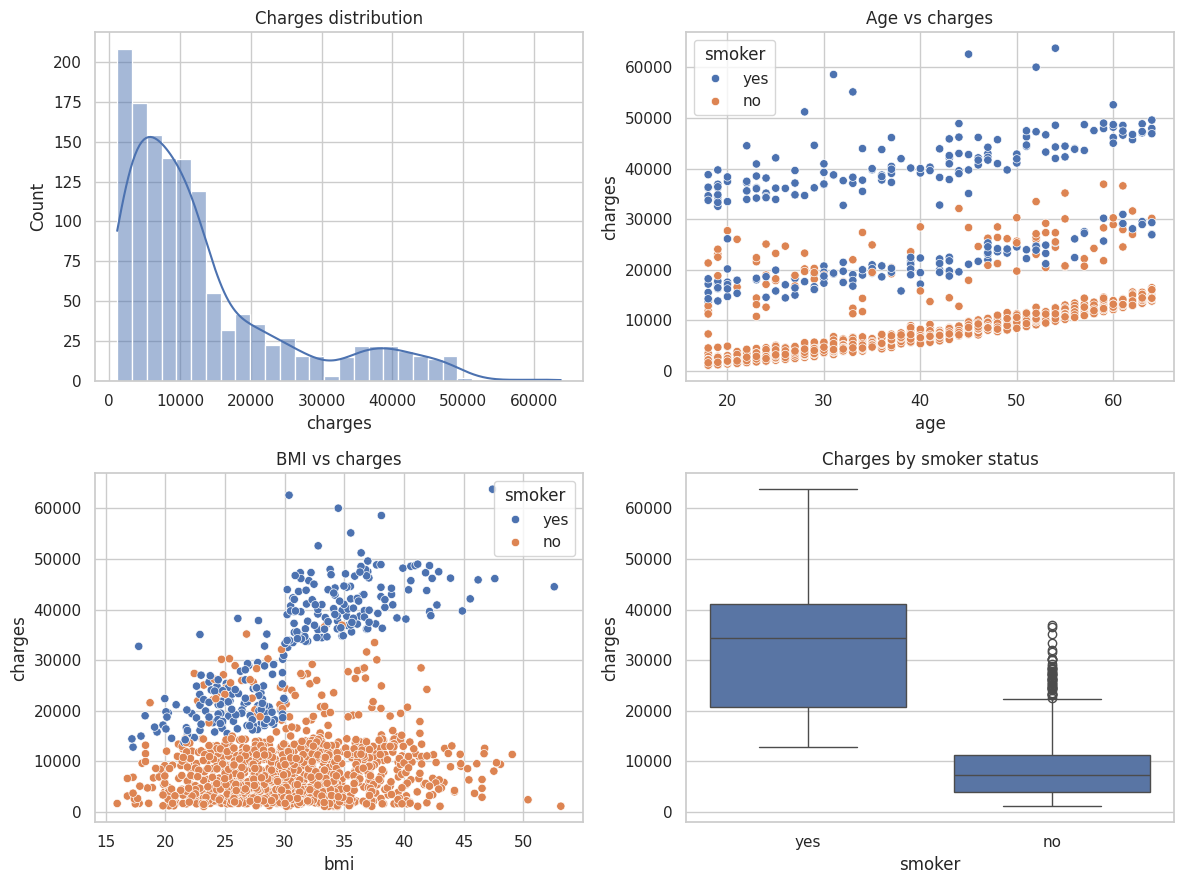

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(df['charges'], kde=True, ax=ax[0, 0]); ax[0, 0].set_title('Charges distribution')
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=ax[0, 1]); ax[0, 1].set_title('Age vs charges')
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=ax[1, 0]); ax[1, 0].set_title('BMI vs charges')
sns.boxplot(data=df, x='smoker', y='charges', ax=ax[1, 1]); ax[1, 1].set_title('Charges by smoker status')
plt.tight_layout(); plt.show()

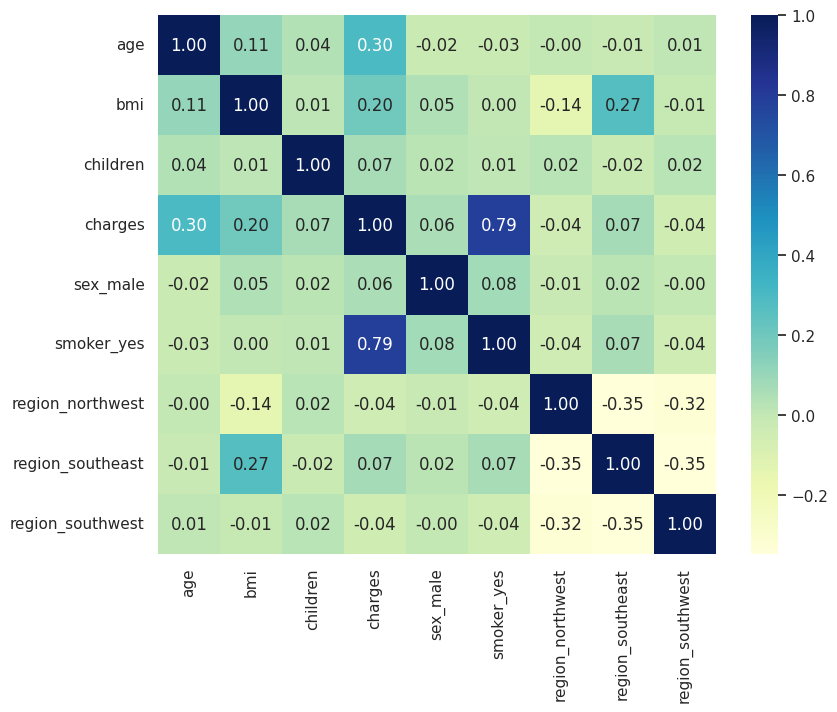

In [6]:
df_enc = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(9, 7))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns='charges')
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols),
])

(1070, 6) (268, 6)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lin_model = Pipeline([('prep', preprocess), ('reg', LinearRegression())])
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    return {'Model': name,
            'R2': r2_score(y_true, y_pred),
            'MSE': mean_squared_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred)}

res_lin = evaluate('Linear Regression', y_test, y_pred_lin)
res_lin

{'Model': 'Linear Regression',
 'R2': 0.7835929767120723,
 'MSE': 33596915.85136146,
 'RMSE': np.float64(5796.2846592762735),
 'MAE': 4181.194473753649}

In [9]:
names = lin_model['prep'].get_feature_names_out()
pd.Series(lin_model['reg'].coef_, index=names).sort_values(key=abs, ascending=False)

,0
cat__smoker_yes,23651.128856
num__age,3614.975415
num__bmi,2036.228123
cat__region_southwest,-809.799354
cat__region_southeast,-657.864297
num__children,516.890247
cat__region_northwest,-370.677326
cat__sex_male,-18.591692


In [10]:
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

def make_svr(**params):
    return TransformedTargetRegressor(
        regressor=Pipeline([('prep', preprocess), ('svr', SVR(**params))]),
        transformer=StandardScaler())

svr_base = make_svr(kernel='rbf')
svr_base.fit(X_train, y_train)
res_svr_base = evaluate('SVR (default RBF)', y_test, svr_base.predict(X_test))
res_svr_base

{'Model': 'SVR (default RBF)',
 'R2': 0.847357842219677,
 'MSE': 23697501.36756228,
 'RMSE': np.float64(4868.007946538531),
 'MAE': 2543.4366279540905}

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__svr__kernel': ['rbf', 'linear'],
    'regressor__svr__C': [0.1, 1, 10, 100],
    'regressor__svr__gamma': ['scale', 0.01, 0.1],
    'regressor__svr__epsilon': [0.05, 0.1, 0.2],
}
grid = GridSearchCV(make_svr(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV R2 :', round(grid.best_score_, 4))

Best params: {'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.1, 'regressor__svr__kernel': 'rbf'}
Best CV R2 : 0.834


In [12]:
svr_best = grid.best_estimator_
y_pred_svr = svr_best.predict(X_test)
res_svr_best = evaluate('SVR (tuned)', y_test, y_pred_svr)
res_svr_best

{'Model': 'SVR (tuned)',
 'R2': 0.8691142393369278,
 'MSE': 20319848.313277826,
 'RMSE': np.float64(4507.75424277742),
 'MAE': 2386.8270838469098}

In [13]:
results = pd.DataFrame([res_lin, res_svr_base, res_svr_best]).set_index('Model')
results.round(4)

,R2,MSE,RMSE,MAE
Model,,,,
Linear Regression,0.7836,3.359692e+07,5796.2847,4181.1945
SVR (default RBF),0.8474,2.369750e+07,4868.0079,2543.4366
SVR (tuned),0.8691,2.031985e+07,4507.7542,2386.8271


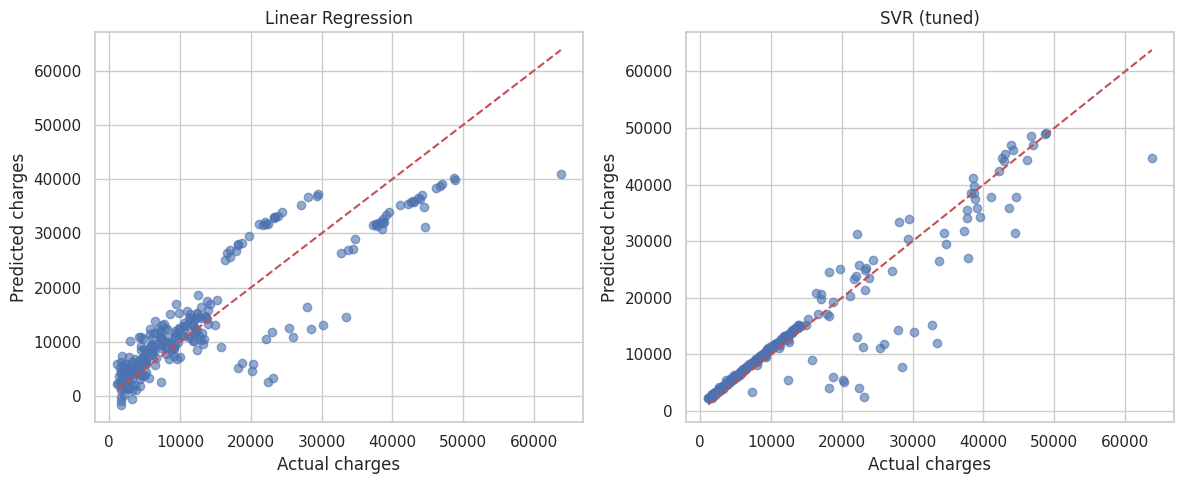

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, pred, title in zip(ax, [y_pred_lin, y_pred_svr], ['Linear Regression', 'SVR (tuned)']):
    a.scatter(y_test, pred, alpha=0.6)
    lims = [y_test.min(), y_test.max()]
    a.plot(lims, lims, 'r--')
    a.set_xlabel('Actual charges'); a.set_ylabel('Predicted charges'); a.set_title(title)
plt.tight_layout(); plt.show()

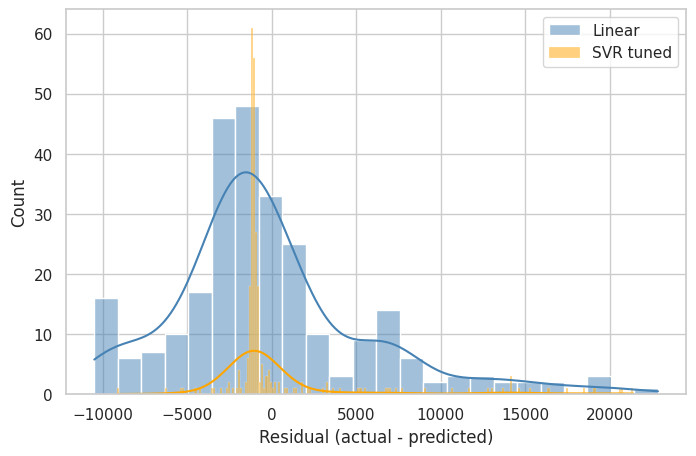

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(y_test - y_pred_lin, color='steelblue', label='Linear', kde=True, alpha=0.5)
sns.histplot(y_test - y_pred_svr, color='orange', label='SVR tuned', kde=True, alpha=0.5)
plt.xlabel('Residual (actual - predicted)'); plt.legend(); plt.show()